## 개선된 스테이블 디퓨전 모델 스크래치 코드

하이퍼파라메터 정의

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# --- 하이퍼파라미터 설정 ---
IMG_SIZE = 128  # 64 → 128로 증가 (VAE 효과를 위해)
LATENT_SIZE = 16  # 128 → 16 (8배 압축)
LATENT_DIM = 8   # Latent space 채널 수
BATCH_SIZE = 64  # VRAM 8GB 활용을 위해 배치 크기 조정
LEARNING_RATE = 2e-4  
EPOCHS = 5  
VAE_PRETRAIN_EPOCHS = 3  # VAE pre-training epochs
TIMESTEPS = 1000  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


데이터셋 준비

In [2]:
class MNISTTextDataset(Dataset):
	"""MNIST 이미지와 해당 숫자에 대한 텍스트 조건을 쌍으로 반환하는 데이터셋
	
	Stable Diffusion의 핵심 개념:
	- 텍스트 조건("A digit 7", "the number 7" 등)을 임베딩으로 변환
	- 다양한 표현이지만 같은 숫자는 같은 임베딩 사용 (데이터 증강 효과)
	- 모델이 이 조건에 맞는 이미지를 생성하도록 학습
	"""
	def __init__(self, mnist_dataset):
		self.mnist_dataset = mnist_dataset
		# 각 숫자에 대한 다양한 텍스트 표현 (데이터 증강)
		# 중요: 다양한 표현이지만, 같은 숫자는 동일한 임베딩(label+1)을 사용
		self.text_prompt_variants = {
			0: ["A digit 0", "the number 0", "zero", "number zero"],
			1: ["A digit 1", "the number 1", "one", "number one"],
			2: ["A digit 2", "the number 2", "two", "number two"],
			3: ["A digit 3", "the number 3", "three", "number three"],
			4: ["A digit 4", "the number 4", "four", "number four"],
			5: ["A digit 5", "the number 5", "five", "number five"],
			6: ["A digit 6", "the number 6", "six", "number six"],
			7: ["A digit 7", "the number 7", "seven", "number seven"],
			8: ["A digit 8", "the number 8", "eight", "number eight"],
			9: ["A digit 9", "the number 9", "nine", "number nine"],
		}

	def __len__(self):
		return len(self.mnist_dataset)

	def __getitem__(self, idx):
		image, label = self.mnist_dataset[idx]
		# 해당 숫자의 다양한 표현 중 랜덤 선택 (데이터 증강)
		text = np.random.choice(self.text_prompt_variants[label])
		# CFG를 위해 레이블을 1~10으로 변환 (0은 빈 프롬프트 예약)
		# 핵심: 프롬프트는 다양하지만, 같은 숫자는 항상 같은 임베딩 인덱스 사용
		# 예: "A digit 7", "seven", "the number 7" 모두 → embedding[8]
		return image, label + 1

# MNIST 데이터셋 로드 및 변환
transform = transforms.Compose([
	transforms.Resize((IMG_SIZE, IMG_SIZE)),
	transforms.ToTensor(),
	transforms.Normalize((0.5,), (0.5,)) # -1 ~ 1 범위로 정규화
])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 데이터셋을 80:20으로 분할
train_size = int(0.8 * len(mnist_train))
val_size = len(mnist_train) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(mnist_train, [train_size, val_size])
print(f"Train dataset size: {train_size}, Validation dataset size: {val_size}")

# 커스텀 데이터셋 적용
train_custom_dataset = MNISTTextDataset(train_dataset)
val_custom_dataset = MNISTTextDataset(val_dataset)

# 데이터로더 생성
train_dataloader = DataLoader(train_custom_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_custom_dataset, batch_size=BATCH_SIZE, shuffle=False)


Train dataset size: 48000, Validation dataset size: 12000


스테이블 디퓨전 유틸리티 함수 정의

In [3]:
def linear_beta_schedule(timesteps):
	"""선형 스케줄에 따라 beta 값들을 생성"""
	beta_start = 0.0001
	beta_end = 0.02
	return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(TIMESTEPS).to(DEVICE)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=DEVICE), alphas_cumprod[:-1]])
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# --- VAE (Variational Autoencoder) for Latent Space ---
class VAEEncoder(nn.Module):
	"""이미지를 latent space로 압축 (128×128 → 16×16×8)"""
	def __init__(self, in_channels=1, latent_dim=LATENT_DIM):
		super().__init__()
		self.encoder = nn.Sequential(
			# 128×128 → 64×64
			nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
			nn.GroupNorm(8, 32),
			nn.SiLU(),
			# 64×64 → 32×32
			nn.Conv2d(32, 64, 3, stride=2, padding=1),
			nn.GroupNorm(8, 64),
			nn.SiLU(),
			# 32×32 → 16×16
			nn.Conv2d(64, 128, 3, stride=2, padding=1),
			nn.GroupNorm(8, 128),
			nn.SiLU(),
			# 16×16 → 16×16 (latent)
			nn.Conv2d(128, latent_dim, 3, padding=1),
		)
	
	def forward(self, x):
		return self.encoder(x)

class VAEDecoder(nn.Module):
	"""Latent space를 이미지로 복원 (16×16×8 → 128×128)"""
	def __init__(self, latent_dim=LATENT_DIM, out_channels=1):
		super().__init__()
		self.decoder = nn.Sequential(
			# 16×16 → 16×16
			nn.Conv2d(latent_dim, 128, 3, padding=1),
			nn.GroupNorm(8, 128),
			nn.SiLU(),
			# 16×16 → 32×32
			nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
			nn.GroupNorm(8, 64),
			nn.SiLU(),
			# 32×32 → 64×64
			nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
			nn.GroupNorm(8, 32),
			nn.SiLU(),
			# 64×64 → 128×128
			nn.ConvTranspose2d(32, out_channels, 4, stride=2, padding=1),
		)
	
	def forward(self, x):
		return self.decoder(x)

def q_sample(x_start, t, noise=None):
	"""Forward Process: 원본 이미지 x_start에 t 시점만큼의 노이즈를 추가"""
	if noise is None:
		noise = torch.randn_like(x_start)
	
	sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
	sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
	
	return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


모델 정의

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
	"""시간(timestep) 정보를 벡터로 변환하는 포지셔널 임베딩"""
	def __init__(self, dim):
		super().__init__()
		self.dim = dim

	def forward(self, time):
		half_dim = self.dim // 2
		embeddings = np.log(10000) / (half_dim - 1)
		embeddings = torch.exp(torch.arange(half_dim, device=DEVICE) * -embeddings)
		embeddings = time[:, None] * embeddings[None, :]
		embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
		return embeddings

class ResNetBlock(nn.Module):
	"""ResNet 스타일의 잔차 연결이 있는 블록"""
	def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
		super().__init__()
		self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
		self.norm1 = nn.GroupNorm(min(8, out_ch//4), out_ch)
		self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
		self.norm2 = nn.GroupNorm(min(8, out_ch//4), out_ch)
		self.time_mlp = nn.Sequential(
			nn.SiLU(),
			nn.Linear(time_emb_dim, out_ch)
		)
		self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
		self.dropout = nn.Dropout(dropout)
		self.silu = nn.SiLU()

	def forward(self, x, t):
		h = self.conv1(x)
		h = self.norm1(h)
		h = self.silu(h)
		
		# 시간 임베딩 추가
		time_emb = self.time_mlp(t)
		h = h + time_emb.unsqueeze(-1).unsqueeze(-1)
		
		h = self.dropout(h)
		h = self.conv2(h)
		h = self.norm2(h)
		
		return self.silu(h + self.shortcut(x))

class AttentionBlock(nn.Module):
	"""Self-Attention 블록"""
	def __init__(self, channels):
		super().__init__()
		self.channels = channels
		self.norm = nn.GroupNorm(min(8, channels//4), channels)
		self.qkv = nn.Conv2d(channels, channels * 3, 1)
		self.proj_out = nn.Conv2d(channels, channels, 1)

	def forward(self, x):
		b, c, h, w = x.shape
		x_norm = self.norm(x)
		qkv = self.qkv(x_norm)
		q, k, v = qkv.chunk(3, dim=1)
		
		# Reshape for attention
		q = q.view(b, c, h * w).transpose(-1, -2)
		k = k.view(b, c, h * w)
		v = v.view(b, c, h * w).transpose(-1, -2)
		
		# Attention
		scale = (c ** (-0.5))
		attn = torch.softmax(q @ k * scale, dim=-1)
		out = (attn @ v).transpose(-1, -2).view(b, c, h, w)
		
		return x + self.proj_out(out)

class ImprovedUNet(nn.Module):
	"""U-Net 모델 with Classifier-Free Guidance (Latent Space용)"""
	def __init__(self, in_channels=LATENT_DIM, out_channels=LATENT_DIM, time_emb_dim=128, text_emb_dim=256):
		super().__init__()
		
		# 텍스트 조건 임베딩
		# - 0: 빈 프롬프트 (무조건부 생성용, CFG에서 사용)
		# - 1~10: "A digit 0" ~ "A digit 9" (조건부 생성용)
		self.text_embedding = nn.Embedding(num_embeddings=11, embedding_dim=text_emb_dim)

		# 시간 임베딩 (더 큰 차원)
		self.time_mlp = nn.Sequential(
			SinusoidalPositionEmbeddings(time_emb_dim),
			nn.Linear(time_emb_dim, time_emb_dim * 2),
			nn.SiLU(),
			nn.Linear(time_emb_dim * 2, time_emb_dim),
		)

		# 초기 projection
		self.init_conv = nn.Conv2d(in_channels, 64, 3, padding=1)

		# Down-sampling path (더 깊은 구조)
		self.down1 = nn.ModuleList([
			ResNetBlock(64, 64, time_emb_dim),
			ResNetBlock(64, 64, time_emb_dim)
		])
		self.down2 = nn.ModuleList([
			ResNetBlock(64, 128, time_emb_dim),
			ResNetBlock(128, 128, time_emb_dim),
			AttentionBlock(128)
		])
		self.down3 = nn.ModuleList([
			ResNetBlock(128, 256, time_emb_dim),
			ResNetBlock(256, 256, time_emb_dim),
			AttentionBlock(256)
		])
		self.down4 = nn.ModuleList([
			ResNetBlock(256, 512, time_emb_dim),
			ResNetBlock(512, 512, time_emb_dim)
		])

		# Middle blocks with text injection
		self.mid_block1 = ResNetBlock(512 + text_emb_dim, 512, time_emb_dim)
		self.mid_attn = AttentionBlock(512)
		self.mid_block2 = ResNetBlock(512, 512, time_emb_dim)

		# Up-sampling path
		self.up1 = nn.ModuleList([
			ResNetBlock(512 + 512, 512, time_emb_dim),
			ResNetBlock(512, 512, time_emb_dim),
			ResNetBlock(512, 256, time_emb_dim)
		])
		self.up2 = nn.ModuleList([
			ResNetBlock(256 + 256, 256, time_emb_dim),
			ResNetBlock(256, 256, time_emb_dim),
			ResNetBlock(256, 128, time_emb_dim),
			AttentionBlock(128)
		])
		self.up3 = nn.ModuleList([
			ResNetBlock(128 + 128, 128, time_emb_dim),
			ResNetBlock(128, 128, time_emb_dim),
			ResNetBlock(128, 64, time_emb_dim),
			AttentionBlock(64)
		])
		self.up4 = nn.ModuleList([
			ResNetBlock(64 + 64, 64, time_emb_dim),
			ResNetBlock(64, 64, time_emb_dim)
		])

		# Down/Up sampling operations
		self.downsample = nn.MaxPool2d(2)
		self.upsample1 = nn.ConvTranspose2d(512, 512, 2, 2)
		self.upsample2 = nn.ConvTranspose2d(256, 256, 2, 2)
		self.upsample3 = nn.ConvTranspose2d(128, 128, 2, 2)
		self.upsample4 = nn.ConvTranspose2d(64, 64, 2, 2)

		# 최종 출력 레이어
		self.final_conv = nn.Sequential(
			nn.GroupNorm(8, 64),
			nn.SiLU(),
			nn.Conv2d(64, out_channels, 3, padding=1)
		)

	def forward(self, x, t, text_labels):
		# Classifier-free guidance를 위한 조건 드롭아웃
		# 학습 시에만 10% 확률로 텍스트 조건을 빈 조건(0)으로 대체
		if self.training:
			drop_mask = (torch.rand(text_labels.shape[0], device=text_labels.device) < 0.1)
			text_labels = text_labels.clone()
			text_labels[drop_mask] = 0  # 0을 "빈 프롬프트"로 사용
		
		# 시간 임베딩
		t_emb = self.time_mlp(t)
		
		# 초기 projection
		x = self.init_conv(x)
		
		# Down-sampling with skip connections
		skip_connections = []
		
		# Down 1 (64x64 -> 32x32)
		for layer in self.down1:
			x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 2 (32x32 -> 16x16)
		for layer in self.down2:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 3 (16x16 -> 8x8)
		for layer in self.down3:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 4 (8x8 -> 4x4)
		for layer in self.down4:
			x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Middle with text injection (2x2)
		text_emb = self.text_embedding(text_labels)
		text_emb_expanded = text_emb.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, x.shape[2], x.shape[3])
		x = torch.cat([x, text_emb_expanded], dim=1)
		
		x = self.mid_block1(x, t_emb)
		x = self.mid_attn(x)
		x = self.mid_block2(x, t_emb)
		
		# Up-sampling with skip connections
		# Up 1 (2x2 -> 4x4)
		x = self.upsample1(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up1:
			x = layer(x, t_emb)
		
		# Up 2 (4x4 -> 8x8)
		x = self.upsample2(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up2:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		
		# Up 3 (8x8 -> 16x16)
		x = self.upsample3(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up3:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		
		# Up 4 (16x16 -> 32x32)
		x = self.upsample4(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up4:
			x = layer(x, t_emb)
		
		return self.final_conv(x)


VAE 모델 사전 학습

In [5]:
# VAE 모델 생성
vae_encoder = VAEEncoder(in_channels=1, latent_dim=LATENT_DIM).to(DEVICE)
vae_decoder = VAEDecoder(latent_dim=LATENT_DIM, out_channels=1).to(DEVICE)

print("\n=== VAE Pre-training ===")
print(f"이미지 크기: {IMG_SIZE}×{IMG_SIZE} → Latent 크기: {LATENT_SIZE}×{LATENT_SIZE}×{LATENT_DIM}")
print(f"압축 비율: {(IMG_SIZE // LATENT_SIZE)**2}배\n")

# VAE Pre-training
vae_optimizer = optim.AdamW(list(vae_encoder.parameters()) + list(vae_decoder.parameters()), 
                             lr=LEARNING_RATE, weight_decay=0.01)
vae_criterion = nn.MSELoss()

for epoch in range(VAE_PRETRAIN_EPOCHS):
	vae_encoder.train()
	vae_decoder.train()
	train_loss = 0.0
	
	for images, _ in tqdm(train_dataloader, desc=f"VAE Epoch {epoch+1}/{VAE_PRETRAIN_EPOCHS}"):
		images = images.to(DEVICE)
		
		# Encode → Decode
		latent = vae_encoder(images)
		reconstructed = vae_decoder(latent)
		
		# Reconstruction loss
		loss = vae_criterion(reconstructed, images)
		
		vae_optimizer.zero_grad()
		loss.backward()
		vae_optimizer.step()
		
		train_loss += loss.item()
	
	avg_train_loss = train_loss / len(train_dataloader)
	print(f"VAE Epoch {epoch+1}/{VAE_PRETRAIN_EPOCHS}, Loss: {avg_train_loss:.4f}")

print("VAE Pre-training 완료\n")


=== VAE Pre-training ===
이미지 크기: 128×128 → Latent 크기: 16×16×8
압축 비율: 64배



VAE Epoch 1/3: 100%|██████████| 750/750 [00:20<00:00, 36.94it/s]


VAE Epoch 1/3, Loss: 0.0229


VAE Epoch 2/3: 100%|██████████| 750/750 [00:21<00:00, 35.48it/s]


VAE Epoch 2/3, Loss: 0.0022


VAE Epoch 3/3: 100%|██████████| 750/750 [00:22<00:00, 34.05it/s]

VAE Epoch 3/3, Loss: 0.0014
VAE Pre-training 완료



In [6]:
# VAE를 evaluation 모드로 고정
vae_encoder.eval()
vae_decoder.eval()
for param in vae_encoder.parameters():
	param.requires_grad = False
for param in vae_decoder.parameters():
	param.requires_grad = False

모델 학습

In [7]:
# 검증 함수 추가 (latent space 버전)
@torch.no_grad()
def validate_model(model, val_dataloader, criterion):
	"""검증 데이터셋에서 모델 성능 평가"""
	model.eval()
	val_loss = 0.0
	num_batches = 0
	
	for images, labels in val_dataloader:
		images = images.to(DEVICE)
		labels = labels.to(DEVICE)
		
		# 이미지를 latent space로 인코딩
		latent = vae_encoder(images)
		
		# 랜덤 타임스텝 t 샘플링
		t = torch.randint(0, TIMESTEPS, (latent.shape[0],), device=DEVICE).long()
		
		# 노이즈 생성 및 노이즈가 추가된 latent 생성
		noise = torch.randn_like(latent)
		x_t = q_sample(x_start=latent, t=t, noise=noise)
		
		# 모델을 통해 노이즈 예측
		predicted_noise = model(x_t, t, labels)
		
		# 손실 계산
		loss = criterion(noise, predicted_noise)
		val_loss += loss.item()
		num_batches += 1
	
	model.train()
	return val_loss / num_batches

model = ImprovedUNet(in_channels=LATENT_DIM, out_channels=LATENT_DIM, text_emb_dim=256).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.MSELoss()

# 학습률 스케줄러 추가
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 모델 파라미터 수 출력
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("Training started with Classifier-Free Guidance in Latent Space...")


# Best 모델 저장을 위한 변수 초기화
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
	model.train()
	epoch_loss = 0
	loop = tqdm(train_dataloader, leave=True)
	for batch_idx, (images, labels) in enumerate(loop):
		images = images.to(DEVICE)
		labels = labels.to(DEVICE)
		
		# 0. 이미지를 latent space로 인코딩
		with torch.no_grad():
			latent = vae_encoder(images)
		
		# 1. 랜덤 타임스텝 t 샘플링
		t = torch.randint(0, TIMESTEPS, (latent.shape[0],), device=DEVICE).long()
		
		# 2. 노이즈 생성 및 노이즈가 추가된 latent 생성 (Forward)
		noise = torch.randn_like(latent)
		x_t = q_sample(x_start=latent, t=t, noise=noise)
		
		# 3. 모델을 통해 노이즈 예측
		predicted_noise = model(x_t, t, labels)
		
		# 4. 손실 계산 및 파라미터 업데이트
		loss = criterion(noise, predicted_noise)
		
		optimizer.zero_grad()
		loss.backward()
		
		# Gradient clipping for stability
		torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
		
		optimizer.step()
		
		epoch_loss += loss.item()
		loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
		loop.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
	
	# 검증 손실 계산
	val_loss = validate_model(model, val_dataloader, criterion)
	
	# 학습률 스케줄러 업데이트
	scheduler.step()
	
	# 에포크별 평균 loss 출력
	avg_train_loss = epoch_loss / len(train_dataloader)
	train_losses.append(avg_train_loss)
	val_losses.append(val_loss)
	
	print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")
	
	# Best 모델 저장
	if val_loss < best_val_loss:
		best_val_loss = val_loss
		torch.save(model.state_dict(), 'best_diffusion_mnist_model.pth')
		print(f"New best model saved! Val Loss: {val_loss:.6f}")
	
	# 주기적으로 모델 저장
	if (epoch + 1) % 10 == 0:
		torch.save(model.state_dict(), f'improved_diffusion_mnist_epoch_{epoch+1}.pth')
		print(f"Model saved at epoch {epoch+1}")

print("Training finished.")

Total parameters: 44,681,928
Trainable parameters: 44,681,928
Training started with Classifier-Free Guidance in Latent Space...


Epoch [1/5]: 100%|██████████| 750/750 [01:33<00:00,  8.05it/s, loss=0.062, lr=0.0002] 


Epoch [1/5] - Train Loss: 0.170713, Val Loss: 0.043149
New best model saved! Val Loss: 0.043149


Epoch [2/5]: 100%|██████████| 750/750 [02:37<00:00,  4.76it/s, loss=0.038, lr=0.000181] 


Epoch [2/5] - Train Loss: 0.045040, Val Loss: 0.026780
New best model saved! Val Loss: 0.026780


...

Epoch [3/5] - Train Loss: 0.031360, Val Loss: 0.022446
New best model saved! Val Loss: 0.022446


Epoch [4/5]: 100%|██████████| 750/750 [02:42<00:00,  4.62it/s, loss=0.0262, lr=6.91e-5]


Epoch [4/5] - Train Loss: 0.026536, Val Loss: 0.019966
New best model saved! Val Loss: 0.019966


Epoch [5/5]: 100%|██████████| 750/750 [02:41<00:00,  4.66it/s, loss=0.0204, lr=1.91e-5]


Epoch [5/5] - Train Loss: 0.024564, Val Loss: 0.018853
New best model saved! Val Loss: 0.018853
Training finished.


학습 결과 확인

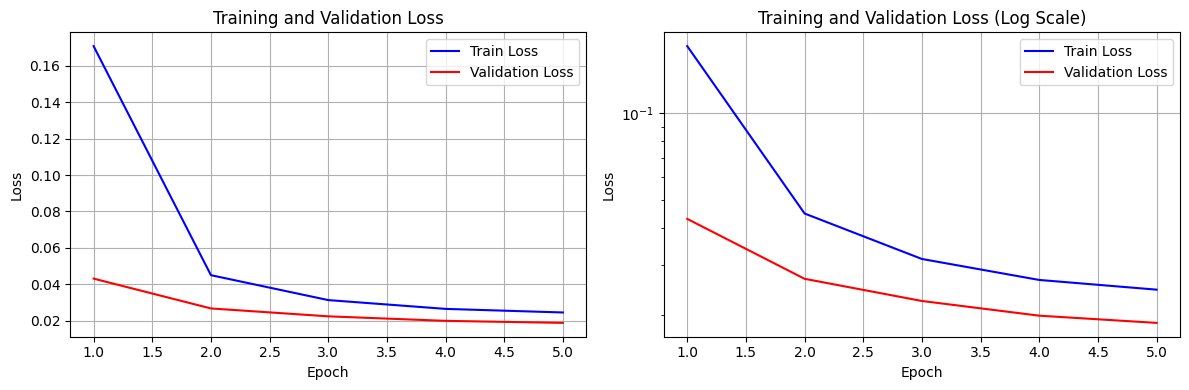

Best validation loss: 0.018853
Training curves saved as 'training_curves.png'
Best model saved as 'best_diffusion_mnist_model.pth'


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best validation loss: {best_val_loss:.6f}")
print("Training curves saved as 'training_curves.png'")
print("Best model saved as 'best_diffusion_mnist_model.pth'")

텍스트 to 이미지 생성 관련 함수 정의

In [9]:
# --- 5. Classifier-Free Guidance 생성 함수 ---
@torch.no_grad()
def generate_image(model, text_label_index, num_images=1, guidance_scale=7.5):
	"""Classifier-Free Guidance가 적용된 이미지 생성 (Latent Space)
	
	Stable Diffusion의 핵심 생성 과정:
	1. 순수 노이즈에서 시작 (latent space에서)
	2. 각 타임스텝마다 노이즈 예측 (조건부 + 무조건부)
	3. CFG로 두 예측을 결합하여 텍스트 조건 강화
	4. 점진적으로 노이즈 제거하여 latent 생성
	5. VAE Decoder로 최종 이미지 변환
	
	Args:
		model: 학습된 diffusion 모델
		text_label_index: 생성할 숫자 (0~9, 예: 7이면 "A digit 7" 생성)
		num_images: 생성할 이미지 개수
		guidance_scale: CFG 강도 (기본값 7.5)
			- 1.0: 조건 무시 (무작위 생성)
			- 3~5: 약한 조건부 생성 (자연스럽지만 덜 정확)
			- 7~9: 강한 조건부 생성 (권장, 정확하고 선명)
			- 15+: 과도하게 강한 조건 (과적합, 품질 저하)
	"""
	model.eval()
	
	# 1. 순수 노이즈에서 시작 (latent space에서)
	shape = (num_images, LATENT_DIM, LATENT_SIZE, LATENT_SIZE)
	latent = torch.randn(shape, device=DEVICE)
	
	# 2. 텍스트 조건 준비
	# - text_labels: "A digit 7" 같은 조건 (1~10 범위)
	# - empty_labels: 빈 프롬프트 "" (0번, CFG용)
	text_labels = torch.tensor([text_label_index + 1] * num_images, device=DEVICE)
	empty_labels = torch.zeros_like(text_labels)

	# 3. Reverse Diffusion: 노이즈에서 latent로 (Stable Diffusion의 핵심)
	for i in tqdm(reversed(range(0, TIMESTEPS)), desc=f'Generating (CFG={guidance_scale})', total=TIMESTEPS, leave=False):
		t = torch.full((num_images,), i, device=DEVICE, dtype=torch.long)
		
		# 4. Classifier-Free Guidance (CFG) - Stable Diffusion의 핵심 기술
		# (1) 무조건부 노이즈 예측: "아무 이미지나" 생성 방향
		noise_uncond = model(latent, t, empty_labels)
		
		# (2) 조건부 노이즈 예측: "A digit 7" 생성 방향
		noise_cond = model(latent, t, text_labels)
		
		# (3) 두 예측을 결합하여 텍스트 조건 강화
		# guidance_scale이 클수록 텍스트 조건을 더 강하게 따름
		predicted_noise = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

		# 4. DDPM 샘플링
		alpha_t = alphas[t].view(-1, 1, 1, 1)
		alpha_t_cumprod = alphas_cumprod[t].view(-1, 1, 1, 1)
		sqrt_one_minus_alpha_t_cumprod = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
		
		model_mean = (1.0 / torch.sqrt(alpha_t)) * (
			latent - (1.0 - alpha_t) / sqrt_one_minus_alpha_t_cumprod * predicted_noise
		)
		
		if i == 0:
			latent = model_mean
		else:
			noise = torch.randn_like(latent)
			posterior_variance = betas[t].view(-1, 1, 1, 1)
			latent = model_mean + torch.sqrt(posterior_variance) * noise
	
	# 5. VAE Decoder로 latent를 이미지로 변환
	images = vae_decoder(latent)
	
	model.train()
	images = (images.clamp(-1, 1) + 1) / 2
	return images.cpu()


텍스트에서 이미지 생성


=== 테스트 1: 다양한 프롬프트 표현 학습 확인 ===
숫자 7에 대한 4가지 프롬프트 표현이 모두 같은 임베딩을 사용하는지 테스트
모두 embedding[8]을 사용하므로 일관된 결과가 나와야 함

Generating with prompt: 'A digit 7' (embedding[8])...


Generating with prompt: 'the number 7' (embedding[8])...


Generating with prompt: 'seven' (embedding[8])...


Generating with prompt: 'number seven' (embedding[8])...


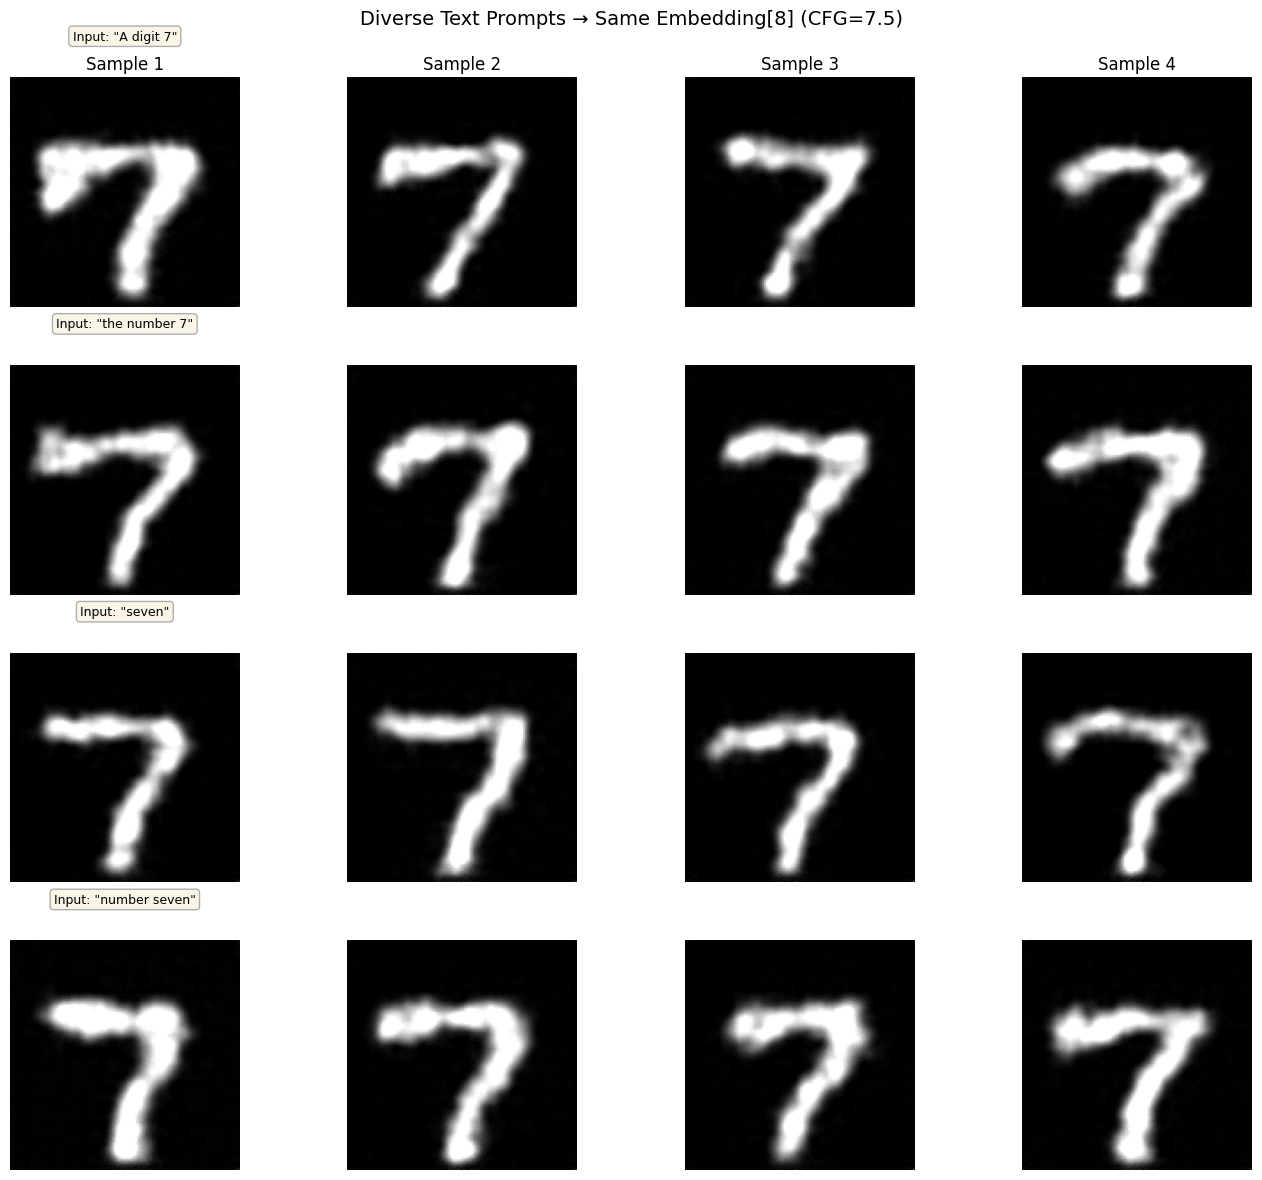

프롬프트 표현 테스트 저장: 'prompt_variants_test.png'
모든 프롬프트가 일관된 숫자 7 이미지를 생성함을 확인



In [10]:
# --- 테스트 1: 다양한 프롬프트 표현 학습 확인 ---
print("\n=== 테스트 1: 다양한 프롬프트 표현 학습 확인 ===")
print("숫자 7에 대한 4가지 프롬프트 표현이 모두 같은 임베딩을 사용하는지 테스트")
print("모두 embedding[8]을 사용하므로 일관된 결과가 나와야 함\n")

target_digit = 7

# 학습 시 사용된 4가지 프롬프트 표현
prompt_variants = [
	"A digit 7",
	"the number 7",
	"seven",
	"number seven"
]

fig, axes = plt.subplots(len(prompt_variants), 4, figsize=(14, 3 * len(prompt_variants)))

for row, prompt_text in enumerate(prompt_variants):
	print(f"Generating with prompt: '{prompt_text}' (embedding[{target_digit+1}])...")
	# 모든 프롬프트가 같은 임베딩을 사용 (label+1)
	generated_images = generate_image(model, target_digit, num_images=4, guidance_scale=7.5)
	
	for col, img_tensor in enumerate(generated_images):
		axes[row, col].imshow(img_tensor.squeeze(), cmap='gray')
		if col == 0:
			axes[row, col].set_ylabel(f'"{prompt_text}"', fontsize=10, wrap=True)
		if row == 0:
			axes[row, col].set_title(f'Sample {col+1}')
		# 이미지 상단에 프롬프트 텍스트 표시 (직관성 향상)
		if col == 0:
			axes[row, col].text(0.5, 1.15, f'Input: "{prompt_text}"', 
			                    transform=axes[row, col].transAxes,
			                    ha='center', va='bottom', fontsize=9, 
			                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
		axes[row, col].axis('off')

plt.suptitle(f'Diverse Text Prompts → Same Embedding[{target_digit+1}] (CFG=7.5)', fontsize=14)
plt.tight_layout()
plt.savefig('prompt_variants_test.png', dpi=300, bbox_inches='tight')
plt.show()
print("프롬프트 표현 테스트 저장: 'prompt_variants_test.png'")
print("모든 프롬프트가 일관된 숫자 7 이미지를 생성함을 확인\n")


CFG 효과 확인


=== 테스트 2: Classifier-Free Guidance 효과 비교 ===
CFG는 Stable Diffusion의 핵심 기술:
- 조건부/무조건부 예측을 결합하여 텍스트 조건을 강화
- guidance_scale로 조건 강도 조절

Generating with guidance_scale=1.0 (No guidance (무작위))...


Generating with guidance_scale=3.0 (Weak guidance (약한 조건))...


Generating with guidance_scale=7.5 (Strong guidance (강한 조건, 권장))...


Generating with guidance_scale=15.0 (Very strong (과도한 조건))...


C:\Users\MAC\AppData\Local\Temp\ipykernel_30788\1707256574.py:37: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MAC\AppData\Local\Temp\ipykernel_30788\1707256574.py:37: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MAC\AppData\Local\Temp\ipykernel_30788\1707256574.py:37: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MAC\AppData\Local\Temp\ipykernel_30788\1707256574.py:38: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.savefig('cfg_effect_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\MAC\AppData\Local\Temp\ipykernel_30788\1707256574.py:38: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.savefig('cfg_effect_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\MAC\AppData\Local\Temp\ipykern

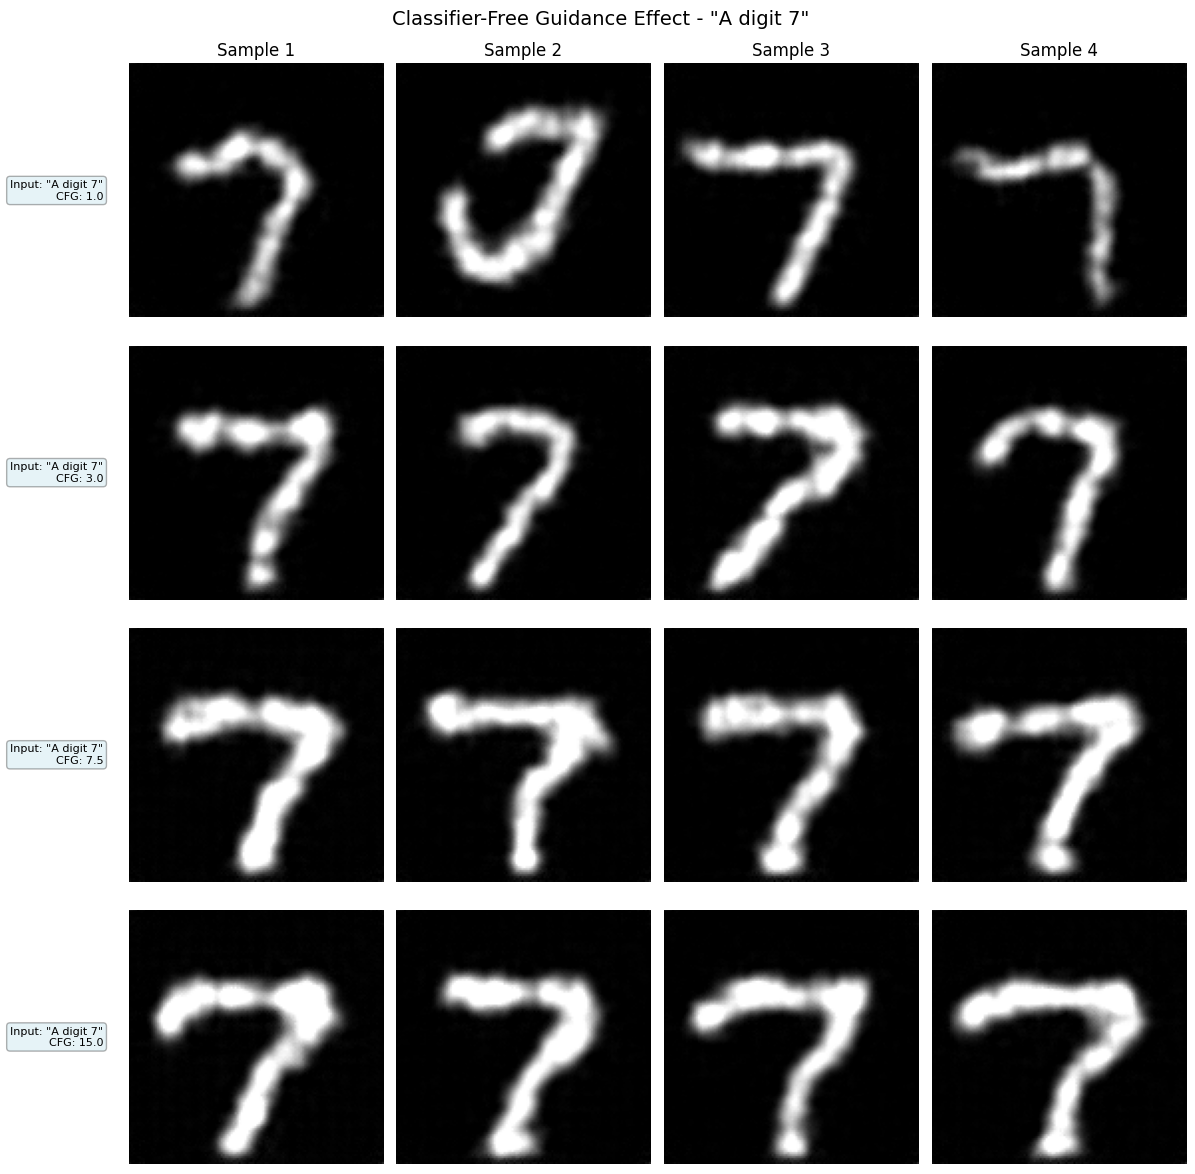

CFG 효과 비교 저장: 'cfg_effect_comparison.png'


In [11]:
# --- 테스트 2: Classifier-Free Guidance 효과 비교 ---
print("\n=== 테스트 2: Classifier-Free Guidance 효과 비교 ===")
print("CFG는 Stable Diffusion의 핵심 기술:")
print("- 조건부/무조건부 예측을 결합하여 텍스트 조건을 강화")
print("- guidance_scale로 조건 강도 조절\n")

# 다양한 guidance_scale로 CFG 효과 비교 (교육적 목적)
guidance_scales = [1.0, 3.0, 7.5, 15.0]
scale_descriptions = [
	"No guidance (무작위)",
	"Weak guidance (약한 조건)",
	"Strong guidance (강한 조건, 권장)",
	"Very strong (과도한 조건)"
]

fig, axes = plt.subplots(len(guidance_scales), 4, figsize=(12, 3 * len(guidance_scales)))

for row, (scale, desc) in enumerate(zip(guidance_scales, scale_descriptions)):
	print(f"Generating with guidance_scale={scale} ({desc})...")
	generated_images = generate_image(model, target_digit, num_images=4, guidance_scale=scale)
	
	for col, img_tensor in enumerate(generated_images):
		axes[row, col].imshow(img_tensor.squeeze(), cmap='gray')
		if col == 0:
			axes[row, col].set_ylabel(f'CFG={scale}\n{desc}', fontsize=10)
		if row == 0:
			axes[row, col].set_title(f'Sample {col+1}')
		# 각 행의 첫 번째 이미지에 input text 표시
		if col == 0:
			axes[row, col].text(-0.1, 0.5, f'Input: "A digit {target_digit}"\nCFG: {scale}', 
			                    transform=axes[row, col].transAxes,
			                    ha='right', va='center', fontsize=8,
			                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
		axes[row, col].axis('off')

plt.suptitle(f'Classifier-Free Guidance Effect - "A digit {target_digit}"', fontsize=14)
plt.tight_layout()
plt.savefig('cfg_effect_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("CFG 효과 비교 저장: 'cfg_effect_comparison.png'")

모델 저장 (VAE 포함)

In [ ]:
torch.save({
	'model': model.state_dict(),
	'vae_encoder': vae_encoder.state_dict(),
	'vae_decoder': vae_decoder.state_dict()
}, 'stable_diffusion_mnist_vae.pth')
print("\nModel saved as 'stable_diffusion_mnist_vae.pth' (with VAE)")



Model saved as 'stable_diffusion_mnist_vae.pth' (with VAE)
